# Grounding DINO 物体検出サンプル

この Notebook では、Grounding DINO を使用してテキストプロンプトで指定した物体の検出を行います。

Grounding DINO は **Zero-Shot 物体検出**が可能で、事前学習済みのクラスに限定されず、自由なテキストで検出対象を指定できます。

In [1]:
# 必要なライブラリのインポート
import cv2
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
from transformers import AutoModelForZeroShotObjectDetection, AutoProcessor

/home/tadashi/develop/blog-experiments/object-detection/grounding-dino/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Grounding DINO モデルの準備

Hugging Face から事前学習済みモデルを初回のみダウンロードします。独自の C++/CUDA 拡張は使用しません。

In [2]:
MODEL_ID = "IDEA-Research/grounding-dino-base"
print(f"Model: {MODEL_ID}")

Model: IDEA-Research/grounding-dino-base


## 2. モデルの読み込み

In [3]:
# モデルの読み込み
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForZeroShotObjectDetection.from_pretrained(MODEL_ID).to(device)
model.eval()

print("Grounding DINO model loaded successfully!")

Using device: cuda
Grounding DINO model loaded successfully!


## 3. 入力画像の読み込み

`images/test1.png` を使用します。

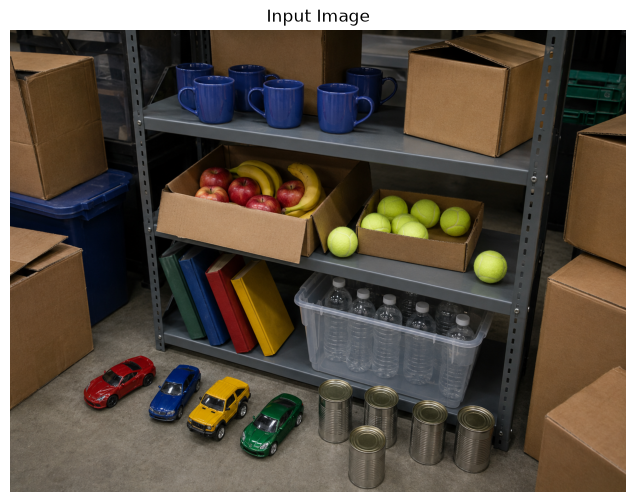

Image size: (1448, 1086)


In [4]:
# 入力画像のパス
image_path = "../assets/test1.png"

# 画像の表示
img = Image.open(image_path)
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis('off')
plt.title("Input Image")
plt.show()

print(f"Image size: {img.size}")

## 4. 検出対象の指定

テキストプロンプトで検出したい物体を指定します。

In [34]:
# 検出対象のリスト
CLASSES = [
    "book",
    "metal shelf",
    "cardboard box",
    "cardboard tray",
    "blue mug",
    "apple",
    "banana",
    "ball",
    "plastic water bottle",
    "clear plastic bin",
    "toy car",
    "tin can",
    "blue storage bin",
    "green plastic crate",
]

# テキストプロンプト（クラスを "." で区切る）
TEXT_PROMPT = ". ".join(CLASSES) + "."

print(f"検出対象: {CLASSES}")
print(f"プロンプト: {TEXT_PROMPT}")

検出対象: ['book', 'metal shelf', 'cardboard box', 'cardboard tray', 'blue mug', 'apple', 'banana', 'ball', 'plastic water bottle', 'clear plastic bin', 'toy car', 'tin can', 'blue storage bin', 'green plastic crate']
プロンプト: book. metal shelf. cardboard box. cardboard tray. blue mug. apple. banana. ball. plastic water bottle. clear plastic bin. toy car. tin can. blue storage bin. green plastic crate.


## 5. 物体検出の実行

Grounding DINO で推論を実行します。

In [35]:
# 画像の読み込み（推論用）
image = Image.open(image_path).convert("RGB")
image_source = np.array(image)

# 推論の実行
BOX_THRESHOLD = 0.35
TEXT_THRESHOLD = 0.25

inputs = processor(images=image, text=TEXT_PROMPT, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model(**inputs)

result = processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    threshold=BOX_THRESHOLD,
    text_threshold=TEXT_THRESHOLD,
    target_sizes=[image.size[::-1]],
)[0]
boxes = result["boxes"].cpu()
logits = result["scores"].cpu()
phrases = result["labels"]

print(f"Detected {len(boxes)} objects")
print(f"\n検出されたフレーズ: {phrases}")

Detected 30 objects

検出されたフレーズ: ['green plastic crate', 'blue storage bin', 'toy car', 'cardboard box', 'toy car', 'clear plastic bin', 'toy car', 'blue mug', 'blue mug', 'metal shelf', 'cardboard box', 'plastic water bottle', 'cardboard box', 'plastic water bottle', 'plastic water bottle', 'blue mug', 'plastic water bottle', 'banana', 'toy car', 'plastic water bottle', 'cardboard box', 'banana', 'tin can', 'apple', 'tin can', 'tin can', 'apple', 'tin can', 'apple', 'tin can']


/home/tadashi/develop/blog-experiments/object-detection/grounding-dino/.venv/lib/python3.12/site-packages/transformers/models/grounding_dino/processing_grounding_dino.py:93: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


## 6. 検出結果の可視化

検出された物体を bounding box と共に表示します。

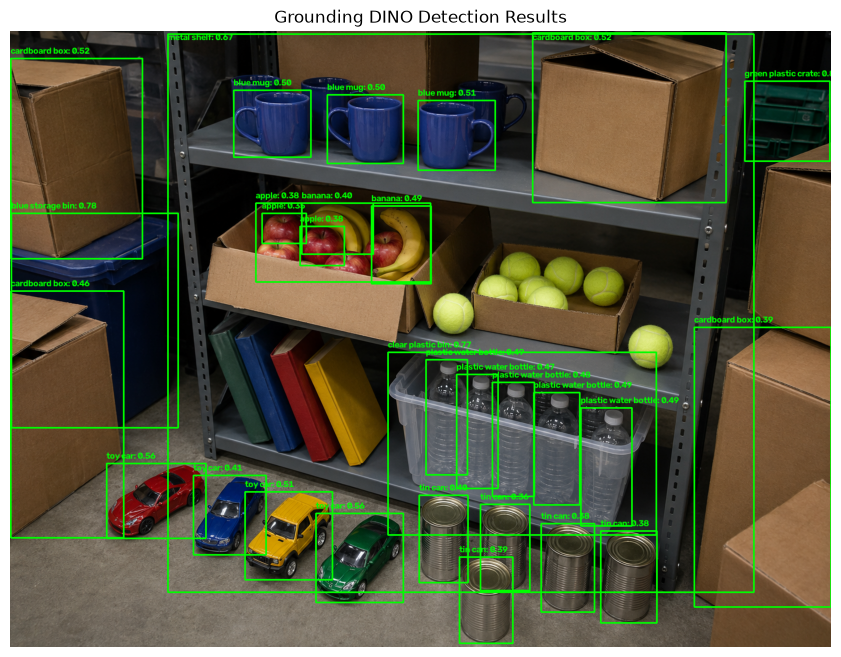

In [36]:
# 検出結果を描画（boxes は画像座標の xyxy 形式）
annotated_frame = image_source.copy()
for box, logit, phrase in zip(boxes, logits, phrases):
    x1, y1, x2, y2 = box.round().int().tolist()
    cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
    label = f"{phrase}: {float(logit):.2f}"
    cv2.putText(annotated_frame, label, (x1, max(y1 - 8, 16)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2, cv2.LINE_AA)

# Matplotlib で表示
plt.figure(figsize=(12, 8))
plt.imshow(annotated_frame)
plt.axis('off')
plt.title("Grounding DINO Detection Results")
plt.show()

## 7. 検出された物体の数の集計

クラスごとの検出数を集計して表示します。

In [37]:
# クラスごとの検出数を集計
import pandas as pd

class_counts = {}
for phrase in phrases:
    phrase_lower = phrase.lower().strip()
    class_counts[phrase_lower] = class_counts.get(phrase_lower, 0) + 1

# データフレームで表示
df_counts = pd.DataFrame(list(class_counts.items()), columns=['クラス', '検出数'])
df_counts = df_counts.sort_values('検出数', ascending=False).reset_index(drop=True)

print("### 検出された物体の数")
print(df_counts.to_string(index=False))
print(f"\n合計: {len(phrases)} 個の物体を検出")

### 検出された物体の数
                 クラス  検出数
             tin can    5
plastic water bottle    5
             toy car    4
       cardboard box    4
            blue mug    3
               apple    3
              banana    2
    blue storage bin    1
 green plastic crate    1
         metal shelf    1
   clear plastic bin    1

合計: 30 個の物体を検出


## 8. 検出された物体の詳細情報

各検出物体のクラス、信頼度、バウンディングボックス座標を表示します。

In [38]:
# 検出結果の詳細を取得
detections = []

for box, logit, phrase in zip(boxes, logits, phrases):
    # box は画像座標の [x1, y1, x2, y2] 形式
    x1, y1, x2, y2 = [float(value) for value in box]
    
    detections.append({
        "class": phrase,
        "confidence": float(logit),
        "bbox": [x1, y1, x2, y2]
    })

# データフレームで表示
df = pd.DataFrame(detections)
df_sorted = df.sort_values('confidence', ascending=False).reset_index(drop=True)
print("\n検出された物体:")
print(df_sorted.to_string(index=False))


検出された物体:
               class  confidence                                                                           bbox
 green plastic crate    0.873381 [1294.6995849609375, 87.68553161621094, 1445.296630859375, 229.49871826171875]
    blue storage bin    0.782898  [2.069697618484497, 321.2609558105469, 296.32171630859375, 698.9186401367188]
   clear plastic bin    0.774649  [666.4517211914062, 566.0755615234375, 1138.6771240234375, 887.8137817382812]
         metal shelf    0.667031  [277.7308044433594, 5.268589019775391, 1311.2501220703125, 989.2076416015625]
             toy car    0.562473      [538.6295776367188, 850.400390625, 693.0508422851562, 1007.2680053710938]
             toy car    0.556645   [170.06312561035156, 762.3128662109375, 344.797607421875, 893.6482543945312]
       cardboard box    0.523084 [921.4484252929688, 3.1850874423980713, 1261.8411865234375, 301.7744445800781]
       cardboard box    0.518500  [1.1200774908065796, 47.67596435546875, 233.0583953857422, 4

## 参考: Grounding DINO のパラメータ

| パラメータ | 説明 | 推奨値 |
|-----------|------|--------|
| `BOX_THRESHOLD` | Bounding box の信頼度閾値 | 0.25 - 0.35 |
| `TEXT_THRESHOLD` | テキストプロンプトとの類似度閾値 | 0.25 - 0.35 |

**調整コツ:**
- 検出数が少なすぎる場合 → 閾値を下げる
- 誤検出が多い場合 → 閾値を上げる
- 特定のクラスのみ検出したい場合 → テキストプロンプトを調整